In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
titanic = pd.read_csv('Titanic-Dataset.csv')

In [8]:
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
titanic.shape

(891, 12)

In [7]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test = train_test_split(titanic, test_size=0.4, random_state=5)

In [15]:
x_nums = x_train[['Age', 'SibSp', 'Parch','Fare']]
x_ct = x_train[['Survived', 'Sex', 'Cabin', 'Embarked', 'Ticket']]

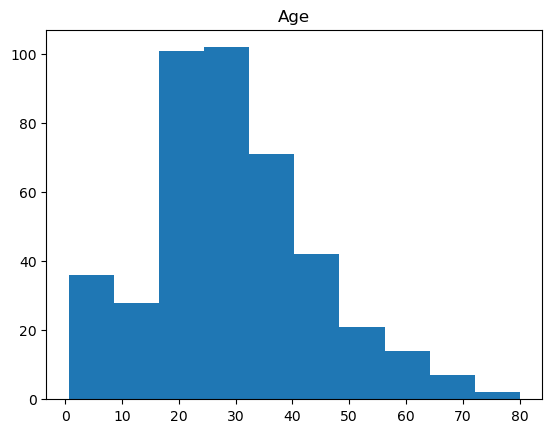

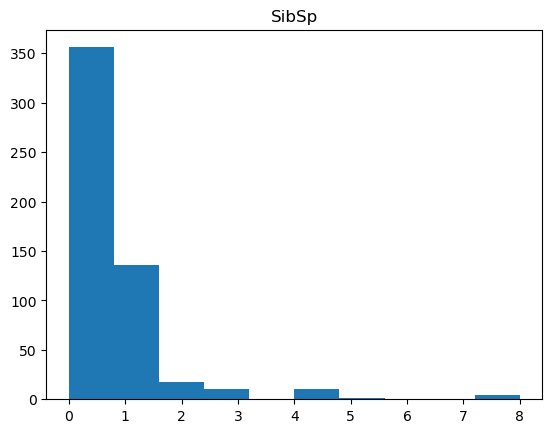

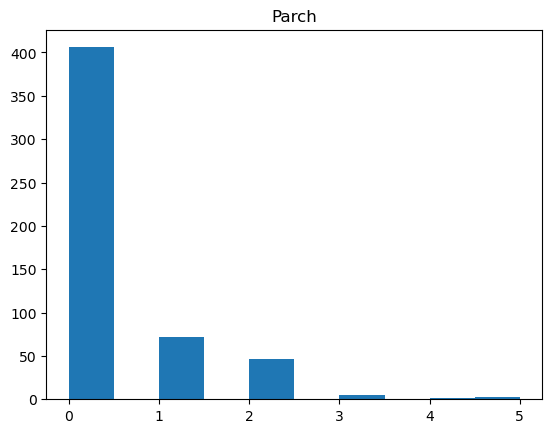

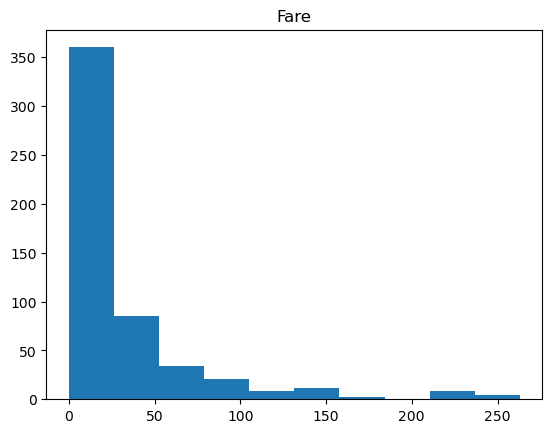

In [16]:
for i in x_nums:
    plt.hist(x_nums[i])
    plt.title(i)
    plt.show()

<Axes: xlabel='Pclass', ylabel='Fare'>

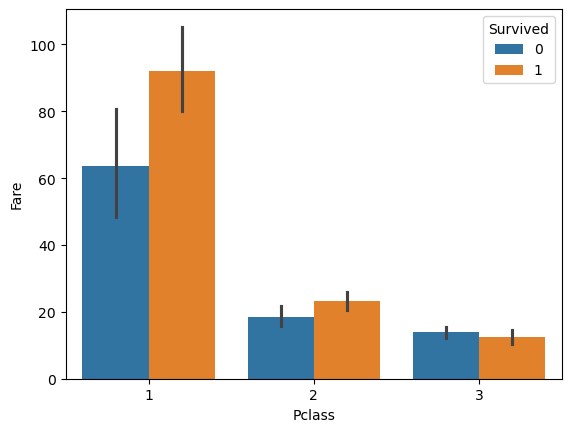

In [19]:
sns.barplot(data=x_train, x='Pclass', y='Fare', hue='Survived')

In [21]:
pd.pivot_table(x_train,index='Survived', values=['Age','SibSp','Fare','Pclass'])

,Age,Fare,Pclass,SibSp
Survived,,,,
0,30.665984,23.013700,2.503106,0.549689
1,28.245833,45.942827,1.976415,0.471698


In [25]:
male = x_train.loc[x_train.Sex == 'male']['Survived']
male_survived = sum(male)/len(male)
female = x_train.loc[x_train.Sex == 'female']['Survived']
female_survived = sum(female)/len(female)

print('male =', male_survived, ' ---- female =', female_survived)

male = 0.19345238095238096  ---- female = 0.7424242424242424


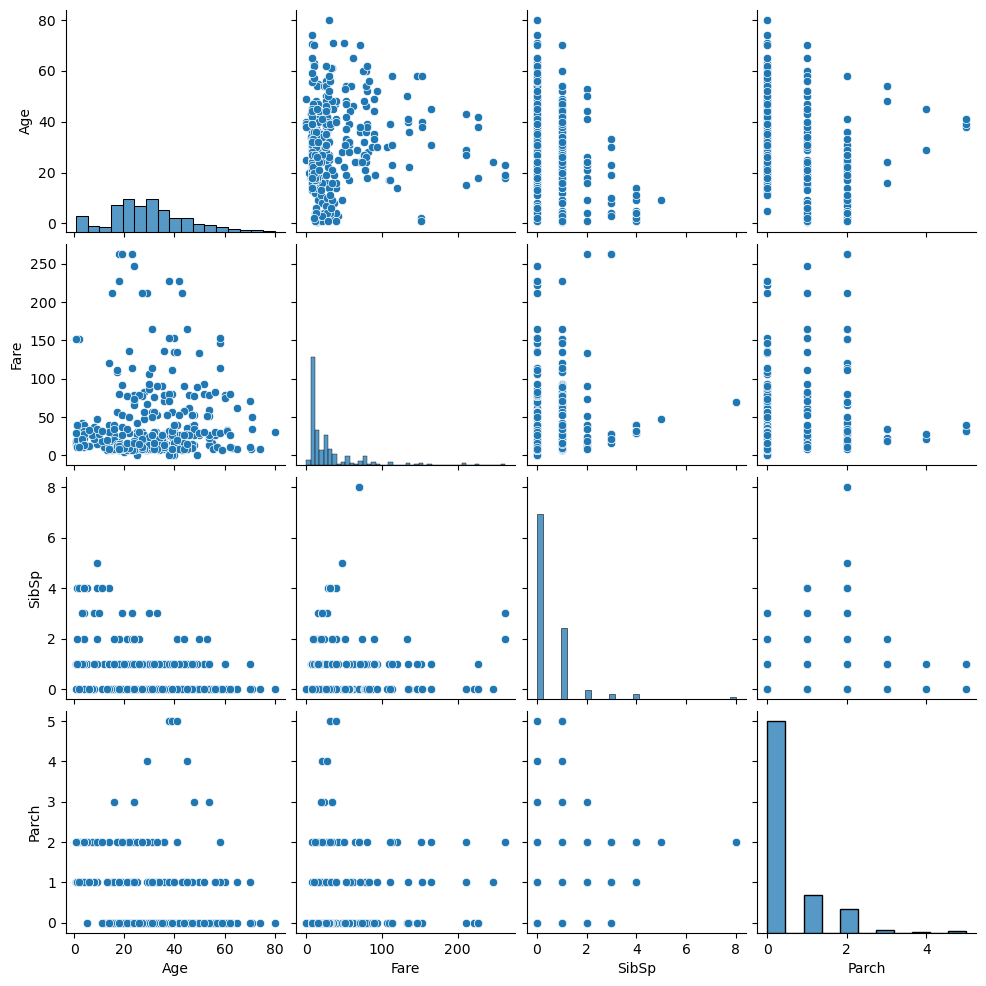

In [27]:
sns.pairplot(x_train[['Age', 'Fare', 'SibSp', 'Parch']])

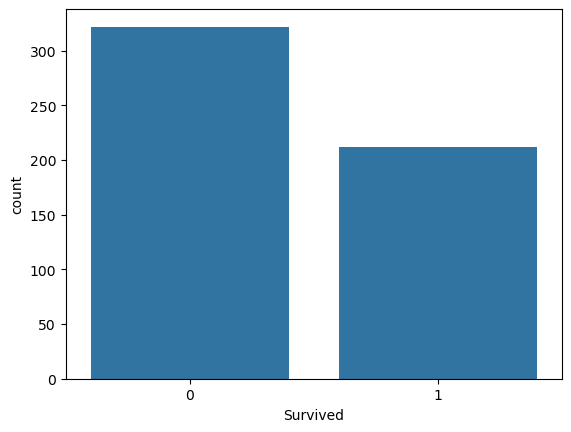

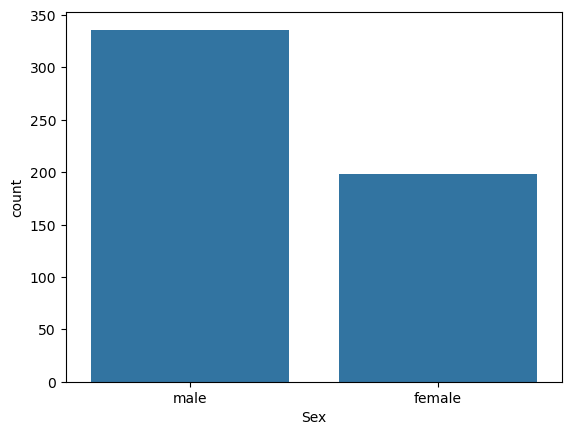

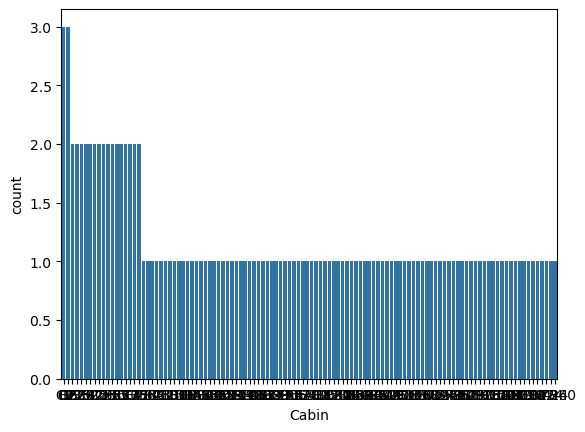

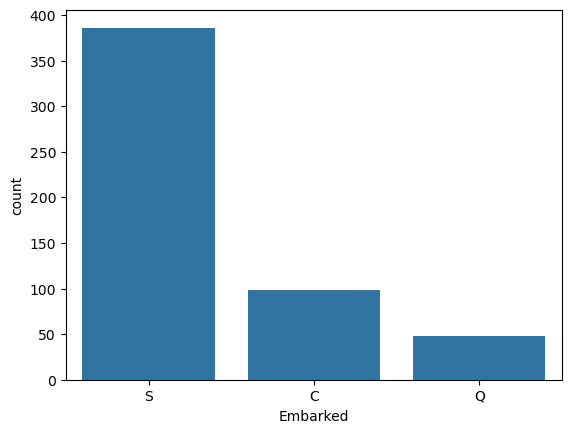

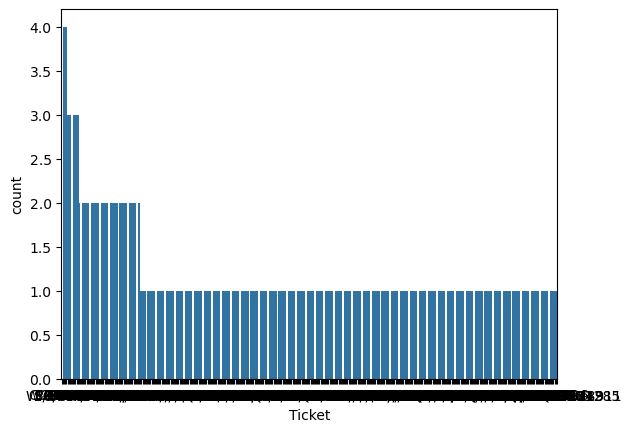

In [29]:
for i in x_ct:
    sns.barplot(x=x_ct[i].value_counts().index, y=x_ct[i].value_counts())
    plt.show()

In [35]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 534 entries, 486 to 867
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  534 non-null    int64  
 1   Pclass    534 non-null    int64  
 2   Sex       534 non-null    object 
 3   Age       424 non-null    float64
 4   SibSp     534 non-null    int64  
 5   Parch     534 non-null    int64  
 6   Fare      534 non-null    float64
 7   Embarked  532 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 37.5+ KB


In [31]:
x_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            110
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          402
Embarked         2
dtype: int64

In [46]:
x_test = x_test.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

In [33]:
x_train = x_train.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

KeyError: "['PassengerId', 'Name', 'Ticket', 'Cabin'] not found in axis"

In [37]:
x_train['Age'] = x_train['Age'].fillna(x_train['Age'].mean())
x_train['Embarked'] = x_train['Embarked'].fillna(x_train['Embarked'].mode()[0])

In [47]:
x_test['Age'] = x_test['Age'].fillna(x_test['Age'].mean())
x_test['Embarked'] = x_test['Embarked'].fillna(x_test['Embarked'].mode()[0])

In [38]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 534 entries, 486 to 867
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  534 non-null    int64  
 1   Pclass    534 non-null    int64  
 2   Sex       534 non-null    object 
 3   Age       534 non-null    float64
 4   SibSp     534 non-null    int64  
 5   Parch     534 non-null    int64  
 6   Fare      534 non-null    float64
 7   Embarked  534 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 37.5+ KB


In [40]:
x_train['Fare']

486     90.0000
726     21.0000
359      7.8792
319    134.5000
661      7.2250
         ...   
400      7.9250
118    247.5208
701     26.2875
206     15.8500
867     50.4958
Name: Fare, Length: 534, dtype: float64

In [41]:
x_train['Fare'] = np.log(x_train['Fare'] + 1)

In [48]:
x_test['Fare'] = np.log(x_test['Fare'] + 1)

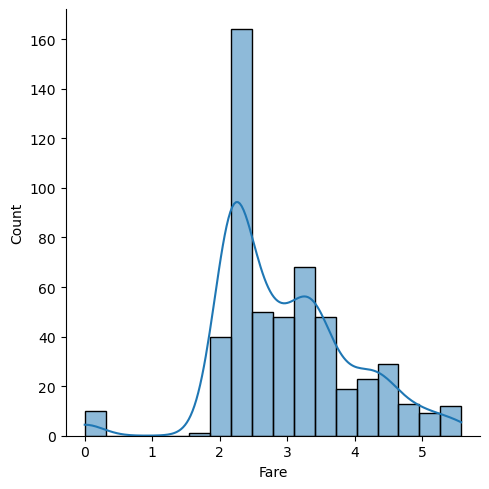

In [42]:
sns.displot(x_train['Fare'], kde=True)

<Axes: >

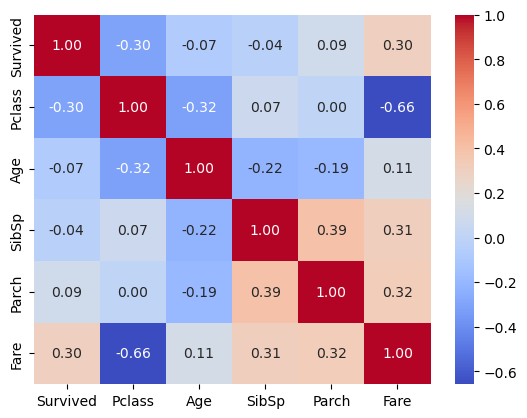

In [44]:
corr = x_train.corr(numeric_only=True)
sns.heatmap(corr, fmt="0.2f", annot=True, cmap='coolwarm')

In [49]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cols = ['Sex','Embarked']
for col in cols:
    x_train[col] = le.fit_transform(x_train[col])
    x_test[col] = le.fit_transform(x_test[col])

x_train.head()
x_test.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
126,0,3,1,29.787655,0,0,2.169054,1
354,0,3,1,29.787655,0,0,2.107178,0
590,0,3,1,35.000000,0,0,2.094946,2
509,1,3,1,26.000000,0,0,4.051712,2
769,0,3,1,32.000000,0,0,2.236712,2


In [50]:
x_train_new = x_train.drop(columns=['Survived'])
x_test_new = x_test.drop(columns=['Survived'])
y_train_new = x_train['Survived']
y_test_new = x_test['Survived']

In [54]:
X = pd.concat([x_train_new, x_test_new])

In [55]:
y = pd.concat([y_train_new, y_test_new])

In [63]:
def classify(model):
    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=40)
    model.fit(x_train,y_train)
    print("Accuracy:", model.score(x_test,y_test))
    score = cross_val_score(model, X, y, cv=5)
    print('CV score:', np.mean(score))
    

In [67]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

model = DecisionTreeClassifier()
classify(model)

Accuracy: 0.7623318385650224
CV score: 0.7744523256543847


In [71]:
from lightgbm import LGBMClassifier
model = LGBMClassifier()
classify(model)

[LightGBM] [Info] Number of positive: 262, number of negative: 406
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000247 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 193
[LightGBM] [Info] Number of data points in the train set: 668, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.392216 -> initscore=-0.438009
[LightGBM] [Info] Start training from score -0.438009
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [74]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
classify(model)

Accuracy: 0.7937219730941704
CV score: 0.7991023790094783


In [73]:
from xgboost import XGBClassifier
model = XGBClassifier()
classify(model)

Accuracy: 0.8161434977578476
CV score: 0.8036218693114054


In [75]:
from sklearn.ensemble import ExtraTreesClassifier
model = ExtraTreesClassifier()
classify(model)

Accuracy: 0.8071748878923767
CV score: 0.7878789780930262


In [76]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
classify(model)

Accuracy: 0.7623318385650224
CV score: 0.7934718473416609


In [79]:
model = XGBClassifier()
model.fit(x_train_new,y_train_new)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [80]:
x_test_new

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
126,3,1,29.787655,0,0,2.169054,1
354,3,1,29.787655,0,0,2.107178,0
590,3,1,35.000000,0,0,2.094946,2
509,3,1,26.000000,0,0,4.051712,2
769,3,1,32.000000,0,0,2.236712,2
...,...,...,...,...,...,...,...
242,2,1,29.000000,0,0,2.442347,2
75,3,1,25.000000,0,0,2.157559,2
219,2,1,30.000000,0,0,2.442347,2
222,3,1,51.000000,0,0,2.202765,2


In [85]:
submit = pd.read_csv('gender_submission.csv')
x_test_reqd = pd.read_csv('test.csv')

In [87]:
x_test_reqd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [88]:
x_test_reqd.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

In [89]:
x_test_reqd['Age'] = x_test_reqd['Age'].fillna(x_test_reqd['Age'].mean())
x_test_reqd['Embarked'] = x_test_reqd['Embarked'].fillna(x_test_reqd['Embarked'].mode()[0])

In [90]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cols = ['Sex','Embarked']
for col in cols:
    x_test_reqd[col] = le.fit_transform(x_test_reqd[col])

x_test_reqd.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,34.5,0,0,7.8292,1
1,3,0,47.0,1,0,7.0000,2
2,2,1,62.0,0,0,9.6875,1
3,3,1,27.0,0,0,8.6625,2
4,3,0,22.0,1,1,12.2875,2


In [91]:
pred = model.predict(x_test_reqd)
pred

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [92]:
submit['Survived'] = pred

In [93]:
submit.to_csv("Submission.csv", index=False)

In [ ]:
#77.03% MODEL ACCURACY!